In [2]:
import pandas as pd
import numpy as np

# Ek complex synthetic dataset generate karte hain jisme bohot se features hain
np.random.seed(42)
n_samples = 500

data = {
    'Age': np.random.randint(18, 70, size=n_samples),
    'Income': np.random.normal(50000, 15000, size=n_samples),
    'Education_Years': np.random.choice([12, 14, 16, 18], size=n_samples),
    'Credit_Score': np.random.normal(650, 100, size=n_samples),
    'Savings_Rate': np.random.uniform(0.0, 0.5, size=n_samples),
    # Kuch correlated (faltu) features dalte hain dimensionality barhane ke liye
    'Feature_X1': np.random.randn(n_samples),
    'Feature_X2': np.random.randn(n_samples),
    'Feature_X3': np.random.randn(n_samples),
    'City': np.random.choice(['Abbottabad', 'Gilgit', 'Islamabad', 'Karachi'], size=n_samples),
    'Target_Label': np.random.choice([0, 1], size=n_samples) # Missing values handle karne ke liye niche missing data dalenge
}

df = pd.DataFrame(data)

# Jaan booch kar kuch missing values aur outliers inject karte hain taake aapki feature engineering test ho
df.loc[df.sample(frac=0.05).index, 'Income'] = np.nan
df.loc[df.sample(frac=0.03).index, 'Credit_Score'] = np.nan
df.loc[df.sample(frac=0.02).index, 'Age'] = 150 # Outlier

# Dataset ko save karein
df.to_csv('practice_dataset.csv', index=False)
print("Dataset successfully created as 'practice_dataset.csv'!")

Dataset successfully created as 'practice_dataset.csv'!


In [3]:
df = pd.read_csv("practice_dataset.csv")

In [4]:
df.head()

,Age,Income,Education_Years,Credit_Score,Savings_Rate,Feature_X1,Feature_X2,Feature_X3,City,Target_Label
0,56,81832.342955,12,674.380071,0.420999,-1.143726,0.500666,1.904137,Abbottabad,0
1,69,65486.978908,16,593.592137,0.364245,0.108560,0.049774,1.625959,Karachi,1
2,46,27209.450511,16,521.969560,0.388224,-0.033230,0.007063,2.218780,Abbottabad,0
3,32,42736.488907,18,737.245733,0.328081,-0.208117,-0.660321,-0.159045,Karachi,0
4,60,69003.667238,16,715.020118,0.088714,-0.128538,0.698828,0.295624,Gilgit,0


In [5]:
df.shape

(500, 10)

In [6]:
# Age column ka deep summary check karein
print(df['Age'].describe())

count    500.000000
mean      46.318000
std       21.015046
min       18.000000
25%       32.000000
50%       45.000000
75%       57.000000
max      150.000000
Name: Age, dtype: float64


In [7]:
# Check karein ke kya koi aisi rows hain jahan Age bohot zyada hai
outliers = df[df['Age'] > 100]
print(f"\nTotal outliers found: {len(outliers)}")
print(outliers[['Age', 'Income']])


Total outliers found: 10
     Age        Income
22   150  35277.370234
33   150  20718.683007
82   150  64626.796001
123  150  38489.786557
142  150  67691.601811
189  150  49509.578779
343  150  42349.754017
402  150  88600.397049
464  150  51713.414730
483  150  57088.962236


In [8]:
# Age ka median nikalwayein (outliers ko chhor kar)
median_age = df[df['Age'] <= 100]['Age'].median()

In [9]:
# Jahan bhi Age 100 se badi hai, wahan median_age daal dein
df.loc[df['Age'] > 100, 'Age'] = median_age

In [10]:
# Check karne ke liye ke koi outlier bacha to nahi
print("Max age after cleaning:", df['Age'].max())

Max age after cleaning: 69


In [11]:
print(df['Age'].describe())

count    500.000000
mean      44.218000
std       14.893559
min       18.000000
25%       32.000000
50%       45.000000
75%       56.250000
max       69.000000
Name: Age, dtype: float64


In [12]:
# check missing values
df.isnull().sum()

Age                 0
Income             25
Education_Years     0
Credit_Score       15
Savings_Rate        0
Feature_X1          0
Feature_X2          0
Feature_X3          0
City                0
Target_Label        0
dtype: int64

In [13]:
# 1. Income ka median nikal kar missing values fill karein
income_median = df['Income'].median()
df['Income'] = df['Income'].fillna(income_median)

In [14]:
# 2. Credit_Score ka median nikal kar missing values fill karein
credit_median = df["Credit_Score"].median()
df["Credit_Score"] = df["Credit_Score"].fillna(credit_median)

In [17]:
df.isnull().sum()

Age                0
Income             0
Education_Years    0
Credit_Score       0
Savings_Rate       0
Feature_X1         0
Feature_X2         0
Feature_X3         0
City               0
Target_Label       0
dtype: int64

In [19]:
# One-Hot Encoding apply karein aur dummy columns ko integer (0/1) me convert karein
df = pd.get_dummies(df, columns = ['City'], drop_first = True, dtype = int)

In [20]:
df.head()

,Age,Income,Education_Years,Credit_Score,Savings_Rate,Feature_X1,Feature_X2,Feature_X3,Target_Label,City_Gilgit,City_Islamabad,City_Karachi
0,56,81832.342955,12,674.380071,0.420999,-1.143726,0.500666,1.904137,0,0,0,0
1,69,65486.978908,16,593.592137,0.364245,0.108560,0.049774,1.625959,1,0,0,1
2,46,27209.450511,16,521.969560,0.388224,-0.033230,0.007063,2.218780,0,0,0,0
3,32,42736.488907,18,737.245733,0.328081,-0.208117,-0.660321,-0.159045,0,0,0,1
4,60,69003.667238,16,715.020118,0.088714,-0.128538,0.698828,0.295624,0,1,0,0


In [26]:
from sklearn.preprocessing import StandardScaler

# Target_Label ko alag kar dein kyunki use scale ya reduce nahi karna
X = df.drop(columns = ['Target_Label'])
y = df['Target_Label']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data successfully scaled! Shape of X_scaled:", X_scaled.shape)

Data successfully scaled! Shape of X_scaled: (500, 11)


In [27]:

from sklearn.decomposition import PCA
import pandas as pd

# 1. PCA object banayein aur target components 2 rakhein
pca = PCA(n_components=2)

# 2. Scaled data par PCA apply karke naye components nikalwein
X_pca = pca.fit_transform(X_scaled)

# 3. Is naye data ko ek saaf suthray DataFrame me convert karein
df_pca = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'])

# 4. Target label ko dobara sath jor dein taake plotting me aasan ho
df_pca['Target'] = y.values

print("PCA successfully applied!")
print("Original shape:", X_scaled.shape)
print("New reduced shape:", df_pca.shape)

PCA successfully applied!
Original shape: (500, 11)
New reduced shape: (500, 3)


In [28]:
# Check karein ke har component ne kitni variance capture ki
variance_retained = pca.explained_variance_ratio_

print(f"PC1 ne capture ki: {variance_retained[0]*100:.2f}% information")
print(f"PC2 ne capture ki: {variance_retained[1]*100:.2f}% information")
print(f"Total Information Retained: {sum(variance_retained)*100:.2f}%")

PC1 ne capture ki: 12.87% information
PC2 ne capture ki: 12.28% information
Total Information Retained: 25.15%


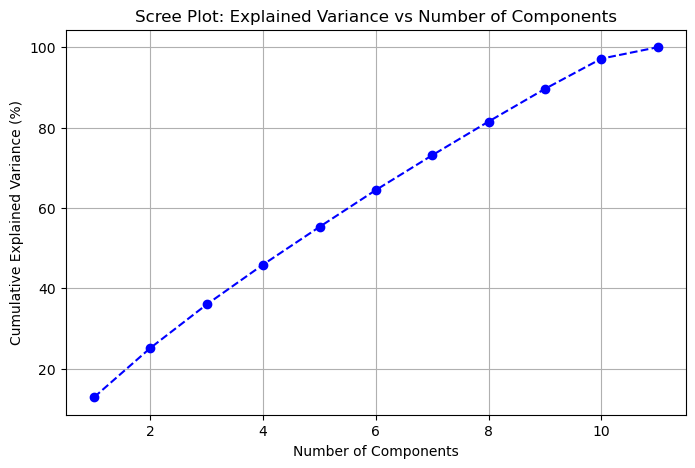

Cumulative Variance list per component:
 [ 12.86714992  25.14577895  35.98006377  45.89728769  55.27438192
  64.45383834  73.11414431  81.50547396  89.63501101  97.15606435
 100.        ]


In [29]:
import matplotlib.pyplot as plt
import numpy as np

# 1. PCA bina kisi component limit ke run karein
pca_full = PCA()
pca_full.fit(X_scaled)

# 2. Cumulative (jama shuda) variance nikalein
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_) * 100

# 3. Plot karke dekhein ke kitne components par kitni information bachti hai
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--', color='b')
plt.title('Scree Plot: Explained Variance vs Number of Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.grid()
plt.show()

print("Cumulative Variance list per component:\n", cumulative_variance)

# Since the generated features are statistically independent and uncorrelated, PCA with 2 components only retains 25.15% of the total variance. The Scree Plot shows a near-linear cumulative variance, indicating that dimensionality reduction cannot be aggressively performed without significant information loss.